# Fashion-MNIST: Advanced Linear Baseline (Multinomial Logistic Regression)
**Feature Extraction:** Histogram of Oriented Gradients (HOG)  
**Data Preprocessing:** Anti-Leakage Standardization (StandardScaler)  
**Architecture:** Multinomial Softmax with L2 Regularization (Ridge)  
**Optimization:** Bayesian Optimization (Optuna) with `lbfgs` solver  
**Validation Strategy:** 5-Seed Repeated Hold-out Validation

## Executive Summary
This notebook establishes a high-performance linear baseline. By employing the `lbfgs` solver and `multinomial` configuration, the model captures cross-entropy relationships across all 10 classes simultaneously. The pipeline follows a rigorous pre-processing protocol to prevent data leakage and utilizes Bayesian search to pinpoint the optimal regularization strength ($C$).

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

from skimage.feature import hog
from joblib import Parallel, delayed

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from cuml.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

# Global settings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.ERROR)
RANDOM_SEED = 42

## 1. Data Engineering & Preprocessing

### 1.1 Data Assembly and Mapping
We load the raw pixel data and align the numerical target IDs with human-readable class names from `labels.csv`.

In [2]:
print("--- 1.1 LOADING DATA ---")

PATH = "/kaggle/input/datasets/owennguyn/fashion-mnist/"

train_df = pd.read_csv(PATH + "data/processed/fashion_mnist_train_60k.csv")
test_df = pd.read_csv(PATH + "data/processed/fashion_mnist_test_10k.csv")
labels_lookup = pd.read_csv(PATH + "data/processed/labels.csv")

# Class Mapping
class_map = dict(zip(labels_lookup['label_id'], labels_lookup['class_name']))
CLASS_NAMES = [class_map[i] for i in range(10)]

y_train_raw = train_df.iloc[:, 0].values
X_train_raw = train_df.iloc[:, 1:].values

X_test_raw = test_df.iloc[:, 1:].values
y_test_raw = test_df.iloc[:, 0].values

print(f"Features Loaded -> Train: {X_train_raw.shape} | Test: {X_test_raw.shape}")

--- 1.1 LOADING DATA ---
Features Loaded -> Train: (60000, 784) | Test: (10000, 784)


### 1.2 Feature Engineering: Histogram of Oriented Gradients (HOG)

Instead of relying on raw pixel intensities, we utilize **Histogram of Oriented Gradients (HOG)** to extract structural features from the Fashion-MNIST images.

**Rationale for using HOG:**
* **Geometric Invariance:** HOG focuses on local gradient orientations, making the model more robust to minor translations, rotations, and lighting variations compared to raw pixels.
* **Shape Description:** By capturing edge directions, HOG effectively describes the "silhouette" and "texture" of garments (e.g., distinguishing the vertical edges of trousers from the curved edges of a pullover).
* **Dimensionality Reduction:** This process transforms the input space from 784 dimensions ($28 \times 28$) to 324 high-quality features, significantly accelerating training without substantial information loss.

The HOG extraction is performed on raw data before any statistical standardization to preserve the original spatial gradients.

In [3]:
def extract_hog_features(images):
    """
    Extracts HOG features using parallel processing to optimize execution on Kaggle/Colab.
    """
    def single_hog(img):
        # Reshape 1D array back to 28x28 for spatial gradient calculation
        return hog(img.reshape(28, 28), 
                   orientations=9, 
                   pixels_per_cell=(7, 7), 
                   cells_per_block=(2, 2), 
                   block_norm='L2-Hys')

    # Utilizing all available CPU cores for efficiency
    features = Parallel(n_jobs=-1)(delayed(single_hog)(i) for i in images)
    return np.array(features).astype(np.float32)

print("--- STAGE 1.2 EXECUTING HOG EXTRACTION ---")
t_hog_start = time.time()

# Process training and testing sets
X_train_hog = extract_hog_features(X_train_raw)
X_test_hog = extract_hog_features(X_test_raw)

print(f"HOG Extraction completed in: {time.time() - t_hog_start:.2f}s")

--- STAGE 1.2 EXECUTING HOG EXTRACTION ---
HOG Extraction completed in: 14.96s


--- STAGE 1.2 VISUALIZING RAW VS HOG IMAGES ---


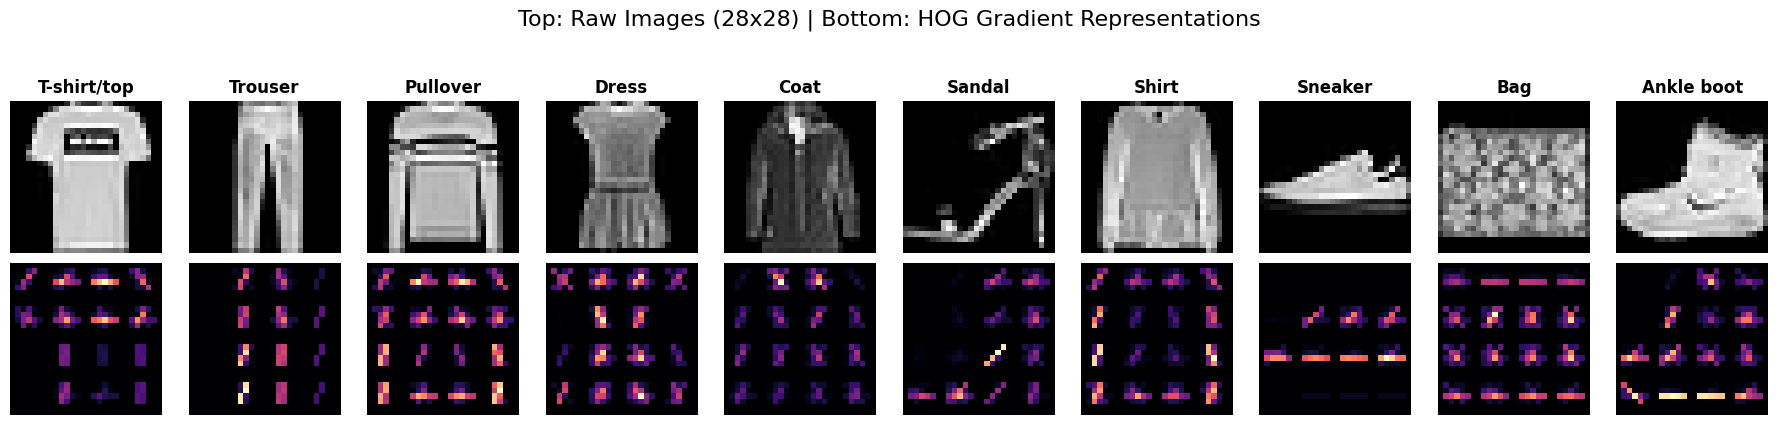

In [4]:
print("--- STAGE 1.2 VISUALIZING RAW VS HOG IMAGES ---")

# 1. Extract exactly one sample index for each of the 10 classes
sample_indices = []
for class_id in range(10):
    idx = np.where(y_train_raw == class_id)[0][0]
    sample_indices.append(idx)

# 2. Initialize the matplotlib figure (2 rows, 10 columns)
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle("Top: Raw Images (28x28) | Bottom: HOG Gradient Representations", fontsize=16, y=1.05)

for col, idx in enumerate(sample_indices):
    # Retrieve the raw image and reshape to 28x28
    img_raw = X_train_raw[idx].reshape(28, 28)
    class_name = CLASS_NAMES[y_train_raw[idx]]
    
    # Generate the 2D HOG image for visualization purposes only (takes < 0.01s per image)
    _, hog_image = hog(img_raw, 
                       orientations=9, 
                       pixels_per_cell=(7, 7), 
                       cells_per_block=(2, 2), 
                       block_norm='L2-Hys', 
                       visualize=True)
    
    # Top Row: Display the Raw Image
    axes[0, col].imshow(img_raw, cmap='gray')
    axes[0, col].set_title(class_name, fontsize=12, fontweight='bold')
    axes[0, col].axis('off')
    
    # Bottom Row: Display the HOG Image (using 'magma' colormap to highlight edge gradients)
    axes[1, col].imshow(hog_image, cmap='magma') 
    axes[1, col].axis('off')

fig.subplots_adjust(hspace=0.5)
plt.tight_layout()
plt.show()

### 1.3 Stratified Split
To prevent split-bias, we use a stratified split to divide the 60,000 samples into 54,000 (Training) and 6,000 (Validation).


In [5]:
print("--- 1.3 STRATIFIED SPLIT ---")

# Split
X_train_54k, X_valid_6k, y_train_54k, y_valid_6k = train_test_split(
    X_train_hog, y_train_raw, test_size=6000, stratify=y_train_raw, random_state=RANDOM_SEED
)

print(f"Training subset   : {X_train_54k.shape}")
print(f"Validation subset : {X_valid_6k.shape}")

--- 1.3 STRATIFIED SPLIT ---
Training subset   : (54000, 324)
Validation subset : (6000, 324)


### 1.4 Anti-Leakage Standardization
The `StandardScaler` is fitted **strictly** on the 54k training subset. This learned mapping is then applied to the validation and test sets to ensure no information from evaluation phases leaks into the training process.

In [6]:
print("--- 1.4 STANDARDIZATION ---")

scaler = StandardScaler()
X_train_54k_scaled = scaler.fit_transform(X_train_54k)
X_valid_6k_scaled = scaler.transform(X_valid_6k)

print("\n--- CHECK SCALED DATA ---")

print("Train mean (should ~0):", np.round(np.mean(X_train_54k_scaled), 4))
print("Train std  (should ~1):", np.round(np.std(X_train_54k_scaled), 4))

print("Valid mean (should ~0):", np.round(np.mean(X_valid_6k_scaled), 4))
print("Valid std  (should ~1):", np.round(np.std(X_valid_6k_scaled), 4))

print("Min/Max Train:",
      np.round(np.min(X_train_54k_scaled), 4),
      np.round(np.max(X_train_54k_scaled), 4))

print("Min/Max Valid:",
      np.round(np.min(X_valid_6k_scaled), 4),
      np.round(np.max(X_valid_6k_scaled), 4))

--- 1.4 STANDARDIZATION ---

--- CHECK SCALED DATA ---
Train mean (should ~0): -0.0
Train std  (should ~1): 1.0
Valid mean (should ~0): -0.0004
Valid std  (should ~1): 1.0004
Min/Max Train: -1.8056 17.6566
Min/Max Valid: -1.8056 13.2571


## 2. Hyperparameter Optimization (Optuna)

### 2.1 Bayesian Search for Regularization (C)
We use the **Tree-structured Parzen Estimator (TPE)** to explore the logarithmic space of $C \in [10^{-2}, 10^{2}]$. The `lbfgs` solver is utilized for its efficiency in second-order optimization.

In [7]:
print("--- 2.1 EXECUTING OPTUNA STUDY ---")

def objective(trial):
    c_val = trial.suggest_float('C', 1e-2, 1e2, log=True)

    clf = LogisticRegression(
        C=c_val, penalty='l2', solver='qn',
        max_iter=1000
    )

    clf.fit(X_train_54k_scaled, y_train_54k)
    y_pred = clf.predict(X_valid_6k_scaled)
    f1 = f1_score(y_valid_6k, y_pred, average='macro')

    print(f"  Trial {trial.number:02d} | C: {c_val:.5f} | Val F1: {f1:.4f}")
    return f1

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=15)

best_C = study.best_params['C']
print(f"\nOptimization Finished! Best C: {best_C:.5f}")

--- 2.1 EXECUTING OPTUNA STUDY ---
  Trial 00 | C: 0.31489 | Val F1: 0.8608
[2026-04-18 18:22:45.658] [CUML] [warning] L-BFGS: max iterations reached
[2026-04-18 18:22:45.658] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  Trial 01 | C: 63.51221 | Val F1: 0.8600
[2026-04-18 18:22:47.186] [CUML] [warning] L-BFGS: max iterations reached
[2026-04-18 18:22:47.186] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.
  Trial 02 | C: 8.47180 | Val F1: 0.8597
[2026-04-18 18:22:48.593] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
  Trial 03 | C: 2.48104 | Val F1: 0.8591
  Trial 04 | C: 0.04208 | Val F1: 0.8592
  Trial 05 | C: 0.04207 | Val F1: 0.8589
  Tri

### 2.2 Optimization Visual Analysis
The history and importance plots visualize the search efficiency of the Bayesian optimizer.

--- STAGE 2.2: OPTIMIZATION PLOTS ---


<Figure size 1000x600 with 0 Axes>

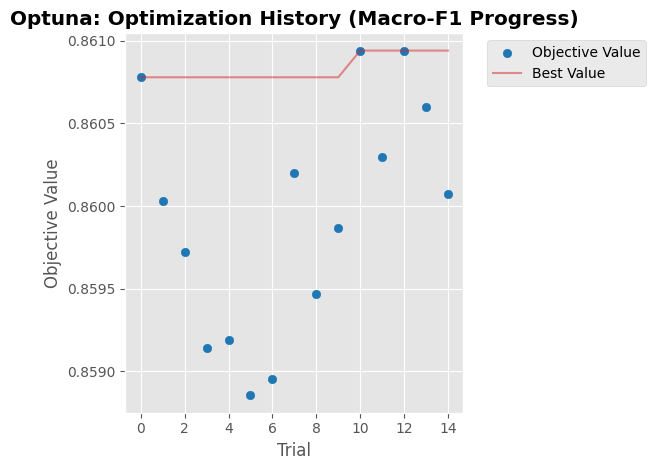

In [8]:
print("--- STAGE 2.2: OPTIMIZATION PLOTS ---")

# Optimization History
plt.figure(figsize=(10, 6))
ax1 = plot_optimization_history(study)
ax1.set_title("Optuna: Optimization History (Macro-F1 Progress)", fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Statistical Stability Check (5-Seed Evaluation Loop)
To confirm the reliability of the discovered `best_C`, we re-evaluate performance across 5 different random seeds, ensuring results are consistent regardless of the data split.

In [9]:
print(f"--- STAGE 3: 5-SEED EVALUATION (C={best_C:.5f}) ---")
seeds = [42, 5435, 123, 2026, 23]
res = {'acc': [], 'f1': [], 'prec': [], 'rec': [], 'train_time': []}

for i, seed in enumerate(seeds):
    # Resplit & Rescale
    X_t_raw, X_v_raw, y_t, y_v = train_test_split(
        X_train_hog, y_train_raw, test_size=6000, stratify=y_train_raw, random_state=seed)

    sc = StandardScaler()
    X_t_s = sc.fit_transform(X_t_raw)
    X_v_s = sc.transform(X_v_raw)

    clf = LogisticRegression(C=best_C, penalty='l2', solver='qn', max_iter=1000)

    # Train and track time
    t_train = time.time()
    clf.fit(X_t_s, y_t)
    train_duration = time.time() - t_train

    # Predict and calculate metrics
    y_p = clf.predict(X_v_s)
    acc = accuracy_score(y_v, y_p)
    f1 = f1_score(y_v, y_p, average='macro')
    prec = precision_score(y_v, y_p, average='macro')
    rec = recall_score(y_v, y_p, average='macro')

    res['train_time'].append(train_duration)
    res['acc'].append(acc); res['f1'].append(f1); res['prec'].append(prec); res['rec'].append(rec)

    print(f"Run {i+1} [Seed {seed:4d}] | Train Time: {train_duration:.2f}s | Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

print("\n--- AGGREGATED METRICS (μ ± σ) ---")
print(f"Accuracy      : {np.mean(res['acc']):.4f} ± {np.std(res['acc']):.4f}")
print(f"Macro-Precision: {np.mean(res['prec']):.4f} ± {np.std(res['prec']):.4f}")
print(f"Macro-Recall   : {np.mean(res['rec']):.4f} ± {np.std(res['rec']):.4f}")
print(f"Macro-F1      : {np.mean(res['f1']):.4f} ± {np.std(res['f1']):.4f}")
print(f"Avg Train Time: {np.mean(res['train_time']):.2f}s per split")

--- STAGE 3: 5-SEED EVALUATION (C=0.31471) ---
Run 1 [Seed   42] | Train Time: 1.14s | Acc: 0.8612 | Prec: 0.8605 | Rec: 0.8612 | F1: 0.8608
Run 2 [Seed 5435] | Train Time: 1.07s | Acc: 0.8533 | Prec: 0.8520 | Rec: 0.8533 | F1: 0.8524
Run 3 [Seed  123] | Train Time: 0.86s | Acc: 0.8520 | Prec: 0.8515 | Rec: 0.8520 | F1: 0.8515
Run 4 [Seed 2026] | Train Time: 0.92s | Acc: 0.8562 | Prec: 0.8554 | Rec: 0.8562 | F1: 0.8556
Run 5 [Seed   23] | Train Time: 0.90s | Acc: 0.8548 | Prec: 0.8541 | Rec: 0.8548 | F1: 0.8543

--- AGGREGATED METRICS (μ ± σ) ---
Accuracy      : 0.8555 ± 0.0032
Macro-Precision: 0.8547 ± 0.0032
Macro-Recall   : 0.8555 ± 0.0032
Macro-F1      : 0.8549 ± 0.0033
Avg Train Time: 0.98s per split


## 4. Final Deployment & Comprehensive Evaluation
The model is retrained on the full 60,000-sample training set. We measure the training time on the full dataset and perform a final, blind evaluation on the 10,000 hold-out test samples.

In [10]:
print("--- STAGE 4: FINAL FULL-DATASET DEPLOYMENT ---")
scaler_final = StandardScaler()
X_train_full_scaled = scaler_final.fit_transform(X_train_hog)
X_test_scaled_final = scaler_final.transform(X_test_hog)

final_clf = LogisticRegression(C=best_C, penalty='l2', solver='qn', max_iter=1000)

# Track Final Training Time
t_final_train = time.time()
final_clf.fit(X_train_full_scaled, y_train_raw)
final_train_time = time.time() - t_final_train
print(f"Model trained on 60,000 samples in {final_train_time:.2f} seconds.")


# Track Inference Latency
t_inf = time.time()
y_test_pred = final_clf.predict(X_test_scaled_final)
latency = (time.time() - t_inf) / len(X_test_scaled_final) * 1000

print("\n[FINAL UNSEEN TEST SET METRICS]")
print(f"Accuracy       : {accuracy_score(y_test_raw, y_test_pred):.4f}")
print(f"Macro-Precision: {precision_score(y_test_raw, y_test_pred, average='macro'):.4f}")
print(f"Macro-Recall   : {recall_score(y_test_raw, y_test_pred, average='macro'):.4f}")
print(f"Macro-F1       : {f1_score(y_test_raw, y_test_pred, average='macro'):.4f}")
print(f"Inference Latency: {latency:.4f} ms/image")

--- STAGE 4: FINAL FULL-DATASET DEPLOYMENT ---
[2026-04-18 18:23:08.257] [CUML] [warning] L-BFGS stopped, because the line search failed to advance (step delta = 0.000000)
Model trained on 60,000 samples in 1.20 seconds.

[FINAL UNSEEN TEST SET METRICS]
Accuracy       : 0.8460
Macro-Precision: 0.8453
Macro-Recall   : 0.8460
Macro-F1       : 0.8454
Inference Latency: 0.0015 ms/image


**Confusion Matrix**

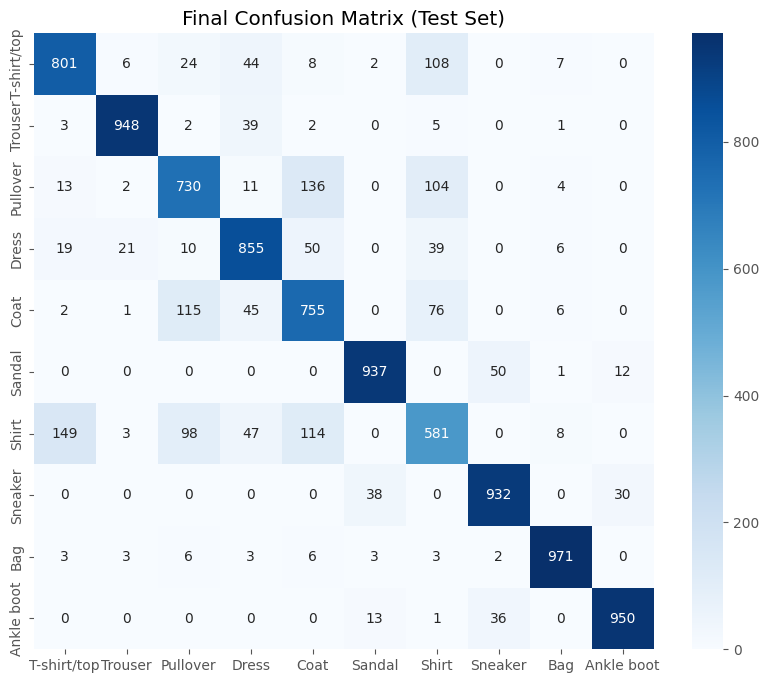

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test_raw, y_test_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Final Confusion Matrix (Test Set)')
plt.show()